In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from algorithm_evaluation import evaluate


### Testing Section

In [72]:
df = evaluate(
            'algorithm_evaluation/example-graphs/bnlearn/large-networks/hailfinder.bif',
            confounder_ratio_range=(0.6, 1.0),
            n_simulations=10,
            seed=42,
            verbose=True,
            experiment_set_size=100,
            theta_config=  {
                'CF_fraction': 0.5,
                'W_sizes': [1,2,3],
                'Z_sizes': [3],
                'intervention_outcome_distances': [3],
            },
            experiment_config={
                'CF_fraction': 0.7,
                'W_sizes': [2],
                'Z_sizes': [5],
            },
            save_graphs="graphs.json"
        )

Graph: hailfinder.bif, |V|=56, |A|=100, ratio_range=(0.6, 1.0)
  u/v=0.79, sim 10/10: pruned 18.0%


In [73]:
df

,graph,n_vars,u_v_ratio,sim,n_confounders,n_districts,query,query_is_cf,min_intervention_outcome_dist,n_R_theta,n_R_theta_star,n_experiments,n_cf_experiments,fraction_cf,n_useless,n_useful,fraction_pruned,id_pruned,blocked_pruned
0,hailfinder.bif,56,0.910714,0,51,13,"Y={'WindFieldPln', 'MountainFcst'}, X={'CombCl...",False,1,11,49,100,71,0.71,28,72,0.28,28,0
1,hailfinder.bif,56,0.642857,1,36,20,"Y={'Boundaries', 'N34StarFcst', 'N0_7muVerMo'}...",False,1,31,33,100,65,0.65,35,65,0.35,33,2
2,hailfinder.bif,56,0.928571,2,52,8,"Y={'LIfr12ZDENSd', 'InsInMt', 'InsSclInScen'},...",True,2,31,51,100,75,0.75,22,78,0.22,22,0
3,hailfinder.bif,56,0.767857,3,43,20,"Y={'N34StarFcst', 'InsSclInScen'}, X={'Date', ...",False,2,40,43,100,75,0.75,23,77,0.23,22,1
4,hailfinder.bif,56,0.678571,4,38,22,"Y={'AreaMeso_ALS', 'MidLLapse', 'MorningBound'...",True,1,10,35,100,67,0.67,21,79,0.21,21,0
5,hailfinder.bif,56,0.607143,5,34,22,"Y={'CombMoisture', 'LLIW'}, X={'SatContMoist',...",False,1,4,30,100,76,0.76,19,81,0.19,19,0
6,hailfinder.bif,56,0.803571,6,45,15,"Y={'LoLevMoistAd', 'MvmtFeatures'}, X={'Scenar...",True,1,4,43,100,69,0.69,32,68,0.32,31,1
7,hailfinder.bif,56,0.696429,7,39,20,"Y={'MorningCIN', 'Date', 'Dewpoints'}, X={'Sce...",True,1,26,37,100,71,0.71,30,70,0.30,29,1
8,hailfinder.bif,56,0.803571,8,45,15,"Y={'CombClouds', 'AreaMeso_ALS'}, X={'QGVertMo...",True,1,14,44,100,65,0.65,30,70,0.30,30,0
9,hailfinder.bif,56,0.785714,9,44,18,"Y={'PlainsFcst', 'MeanRH'}, X={'Scenario', 'LI...",True,1,39,44,100,73,0.73,18,82,0.18,18,0


/home/tobi/research/optimal-experiments-for-partial-ID/algorithm_evaluation/visualize.py:142: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


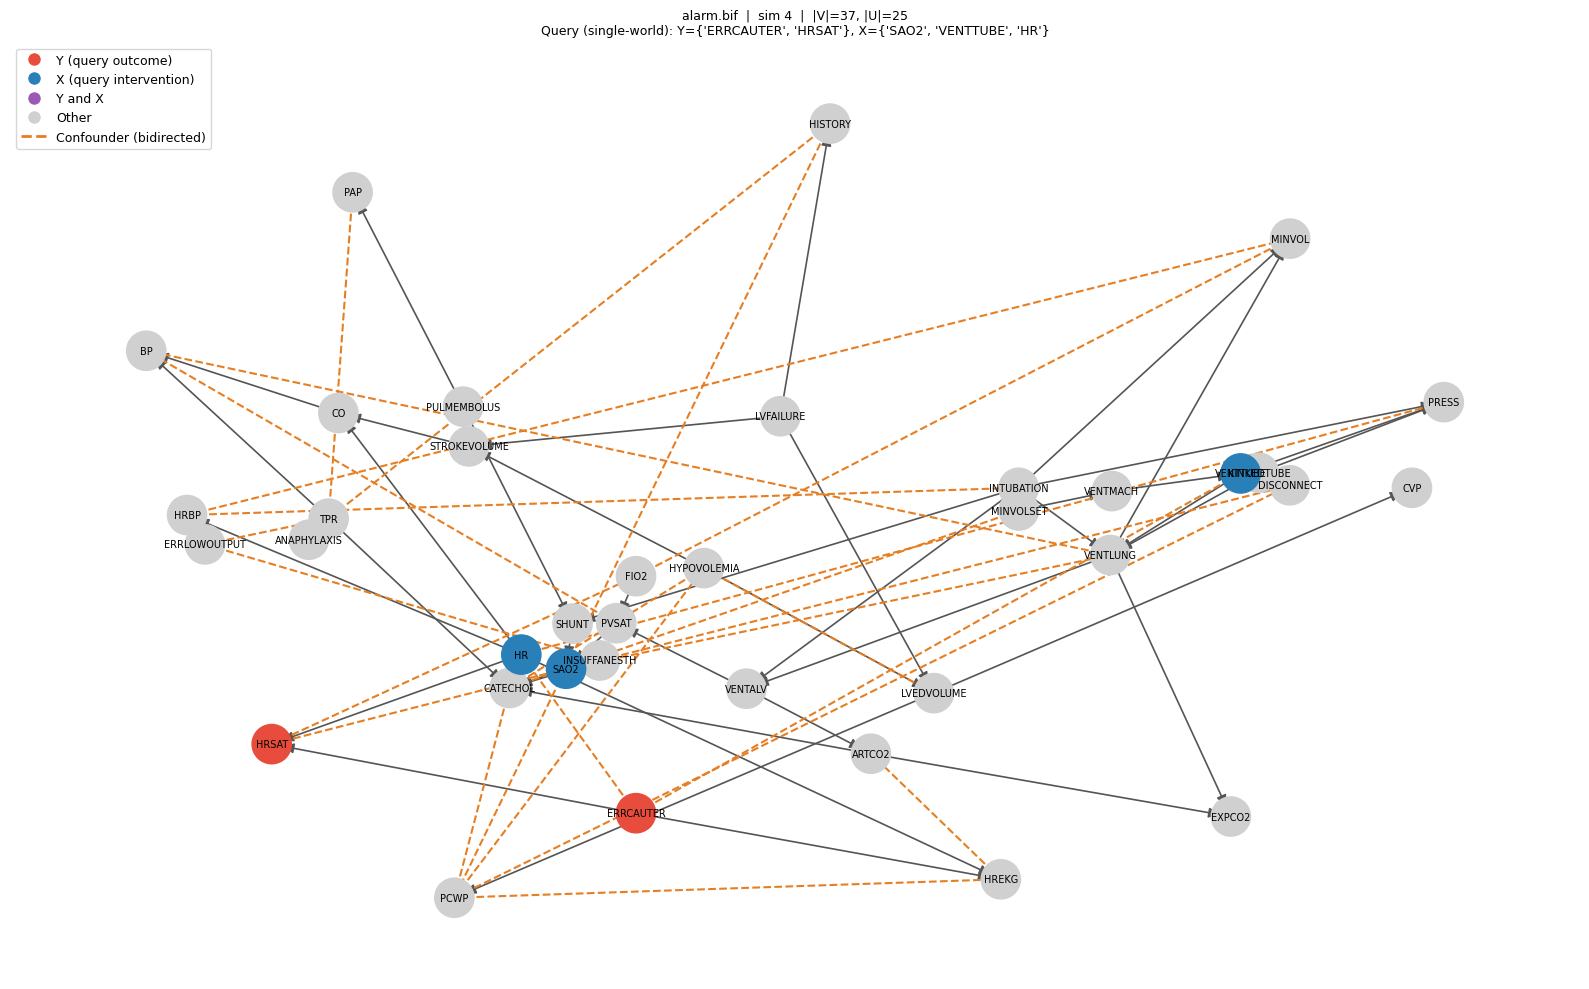

Simulation: alarm.bif  sim=4
|V|=37, |U|=25, |A|=100
Query: Y={'ERRCAUTER', 'HRSAT'}, X={'SAO2', 'VENTTUBE', 'HR'}

--- Useful (69) ---
  [  0] (CF) W={'VENTLUNG', 'HR'}, Z={'TPR', 'DISCONNECT', 'INTUBATION', 'ANAPHYLAXIS', 'KINKEDTUBE'}; W={'VENTLUNG', 'LVFAILURE'}, Z={'VENTMACH', 'INTUBATION', 'MINVOLSET', 'VENTTUBE', 'KINKEDTUBE'}
  [  1] (CF) W={'VENTLUNG', 'HYPOVOLEMIA'}, Z={'VENTMACH', 'INTUBATION', 'MINVOLSET', 'VENTTUBE', 'KINKEDTUBE'}; W={'HYPOVOLEMIA', 'ARTCO2'}, Z={'VENTALV', 'DISCONNECT', 'INTUBATION', 'MINVOLSET', 'KINKEDTUBE'}
  [  2] (CF) W={'EXPCO2', 'FIO2'}, Z={'VENTALV', 'ARTCO2', 'DISCONNECT', 'MINVOLSET', 'VENTTUBE'}; W={'HRBP', 'FIO2'}, Z={'ARTCO2', 'DISCONNECT', 'VENTMACH', 'VENTTUBE', 'PULMEMBOLUS'}
  [  3] (CF) W={'HRBP', 'PVSAT'}, Z={'CATECHOL', 'DISCONNECT', 'TPR', 'MINVOLSET', 'ANAPHYLAXIS'}; W={'TPR', 'PVSAT'}, Z={'VENTLUNG', 'MINVOLSET', 'INTUBATION', 'VENTMACH', 'FIO2'}
  [  4] (CF) W={'VENTLUNG', 'STROKEVOLUME'}, Z={'DISCONNECT', 'INTUBATION', 'MINVOLSET'

In [70]:
from algorithm_evaluation import plot_simulation, print_experiments
sim = 4
# Visualize the graph
plot_simulation("graphs.json", "alarm.bif", sim)

# Print experiments by pruning status
print_experiments("graphs.json", "alarm.bif", sim)

## Across `CF_fraction` values

In [83]:

small_networks= ['asia', 'sachs'] #path: small-networks/
medium_networks = ['alarm', 'barley', 'child', 'insurance', 'mildew', 'water'] # path: medium-networks/
large_networks = ['hailfinder', 'hepar2', 'win95pts'] # path: large-networks/

all_graphs_paths = [f'small-networks/{graph}.bif' for graph in small_networks] + \
                   [f'medium-networks/{graph}.bif' for graph in medium_networks] + \
                   [f'large-networks/{graph}.bif' for graph in large_networks]
df = pd.DataFrame()

path_prefix= 'algorithm_evaluation/example-graphs/bnlearn/'

CF_fractions = [0, 0.25, 0.5, 0.75, 1]
for CF_fraction in CF_fractions:
    print(f"Evaluating CF_fraction: {CF_fraction}")
    for graph_path in all_graphs_paths:
        print(f"Evaluating graph: {graph_path}")
        df = pd.concat([df, evaluate(
            path_prefix + graph_path,
            confounder_ratio_range=(0.05, 0.8), #maybe for next run: (0.5, 1.0) -> less ID alg domination
            n_simulations=50,
            seed=42,
            verbose=True,
            experiment_set_size=200,
            theta_config=  {
                'CF_fraction': 0.5,
                'W_sizes': [1, 2, 3, 4, 5],
                'Z_sizes': [1, 2, 3, 4, 5],
                'intervention_outcome_distances': [1,2,3,4,5],
            },
            experiment_config={
                'CF_fraction': CF_fraction,
                'W_sizes': [1, 2, 3, 4, 5],
                'Z_sizes': [1, 2, 3, 4, 5],
            }
        )], ignore_index=True)
df.to_csv('algorithm_evaluation/results/04_04__slide_across_CF_fraction.csv', index=False)

Evaluating CF_fraction: 0
Evaluating graph: small-networks/asia.bif
Graph: asia.bif, |V|=8, |A|=200, ratio_range=(0.05, 0.8)
  u/v=0.25, sim 10/50: pruned 57.5%
  u/v=0.38, sim 20/50: pruned 57.5%
  u/v=0.50, sim 30/50: pruned 42.0%
  u/v=0.25, sim 40/50: pruned 77.0%
  u/v=0.12, sim 50/50: pruned 100.0%
Evaluating graph: small-networks/sachs.bif
Graph: sachs.bif, |V|=11, |A|=200, ratio_range=(0.05, 0.8)
  u/v=0.55, sim 10/50: pruned 50.0%
  u/v=0.73, sim 20/50: pruned 20.0%
  u/v=0.73, sim 30/50: pruned 41.5%
  u/v=0.73, sim 40/50: pruned 52.5%
  u/v=0.55, sim 50/50: pruned 47.5%
Evaluating graph: medium-networks/alarm.bif
Graph: alarm.bif, |V|=37, |A|=200, ratio_range=(0.05, 0.8)
  u/v=0.11, sim 10/50: pruned 88.5%
  u/v=0.27, sim 20/50: pruned 99.5%
  u/v=0.38, sim 30/50: pruned 83.5%
  u/v=0.65, sim 40/50: pruned 90.0%
  u/v=0.27, sim 50/50: pruned 93.5%
Evaluating graph: medium-networks/barley.bif
Graph: barley.bif, |V|=48, |A|=200, ratio_range=(0.05, 0.8)
  u/v=0.54, sim 10/50: p

In [3]:
df = pd.read_csv('algorithm_evaluation/results/03_04__slide_across_CF_fraction.csv')

In [4]:
print(df.head(3))

      graph  n_vars  u_v_ratio  sim  n_confounders  n_districts  \
0  asia.bif       8      0.500    0              4            4   
1  asia.bif       8      0.500    1              4            4   
2  asia.bif       8      0.375    2              3            5   

                                               query  query_is_cf  \
0  Y={'dysp', 'smoke', 'asia', 'either'}, X={'lun...        False   
1             Y={'lung', 'tub', 'dysp'}, X={'bronc'}        False   
2  Y={'dysp', 'bronc', 'tub', 'either'}, X={'lung...        False   

   min_intervention_outcome_dist  n_R_theta  n_R_theta_star  n_experiments  \
0                              1          4               4            200   
1                              1          4               4            200   
2                              1          3               3            200   

   n_cf_experiments  fraction_cf  n_useless  n_useful  fraction_pruned  \
0                 0          0.0         76       124            0.

In [92]:
df['U_over_V'] = df['n_confounders'] / df['n_vars']
df['n_vars'].corr(df['U_over_V'])

# find average 'U_over_V' per graph
graph_col = 'graph_name' if 'graph_name' in df.columns else 'graph'
avg_U_over_V_per_graph = df.groupby(graph_col)['U_over_V'].mean().sort_values()
print(avg_U_over_V_per_graph)

graph
hepar2.bif        0.387257
hailfinder.bif    0.407429
insurance.bif     0.422815
mildew.bif        0.423314
water.bif         0.425000
alarm.bif         0.426919
win95pts.bif      0.430000
barley.bif        0.438000
child.bif         0.443000
sachs.bif         0.449818
asia.bif          0.478000
Name: U_over_V, dtype: float64


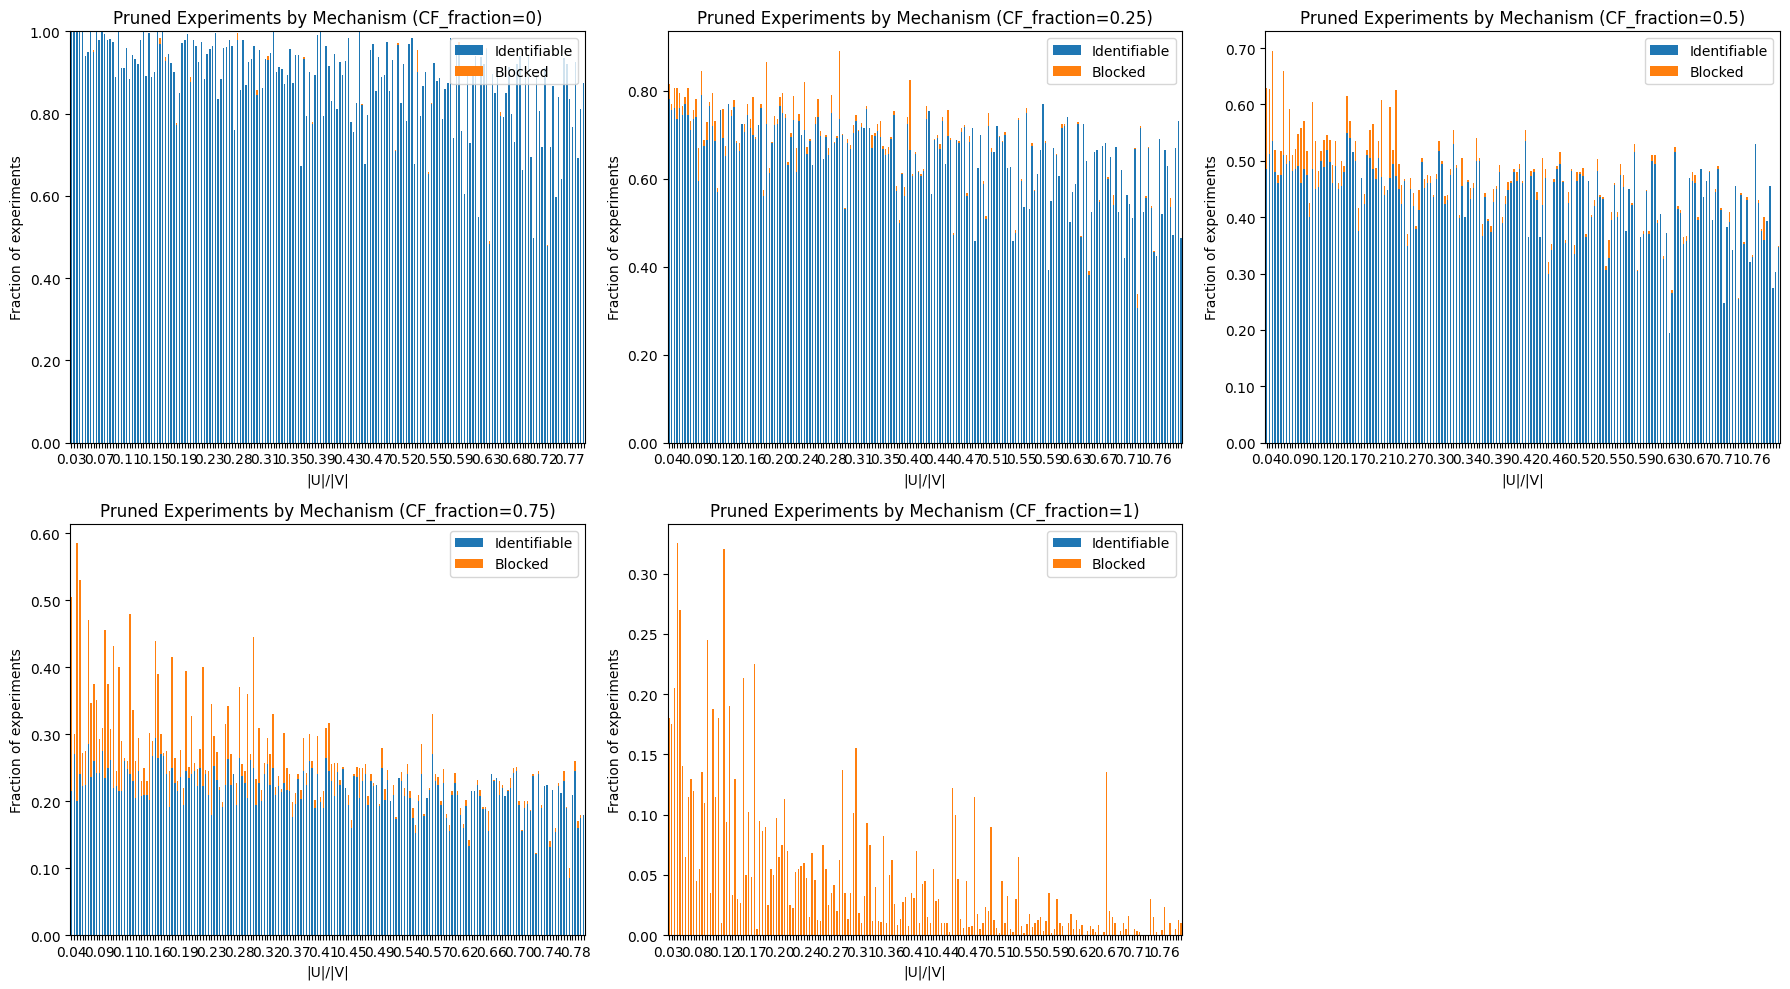

In [95]:
n_rows = 2
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
flat_axes = axes.flatten()

tol = 0.05
source_df = df if not df.empty else df_cf

CF_fractions = [0, 0.25, 0.5, 0.75, 1]

for idx, cf in enumerate(CF_fractions):
    ax = flat_axes[idx]

    mask = source_df["fraction_cf"].between(cf - tol, cf + tol)
    d = source_df.loc[mask]

    # ax.set_ylim(0, 1)

    if d.empty:
        ax.set_title(f"Pruned Experiments by Mechanism (CF_fraction={cf})\nNo data")
        ax.set_xlabel("|U|/|V|")
        ax.set_ylabel("Fraction of experiments")
        continue

    p = pd.DataFrame({
        "fraction_id": d["id_pruned"] / d["n_experiments"],
        "fraction_blocked": d["blocked_pruned"] / d["n_experiments"],
        "fraction_confounders": d["n_confounders"] / d["n_vars"],
    })

    p = p.groupby("fraction_confounders", as_index=True)[["fraction_id", "fraction_blocked"]].mean()
    p.index = p.index.round(2)

    p.plot(kind="bar", stacked=True, ax=ax)

    ax.set_xlabel("|U|/|V|")
    ax.set_ylabel("Fraction of experiments")
    ax.set_title(f"Pruned Experiments by Mechanism (CF_fraction={cf})")
    ax.legend(["Identifiable", "Blocked"])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    # ax.set_ylim(0, 1)

    xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
    ax.set_xticklabels(xlabels, rotation=0)

for j in range(len(CF_fractions), len(flat_axes)):
    flat_axes[j].set_visible(False)

fig.tight_layout()
plt.show()


## Across `intervention_outcome_distances`

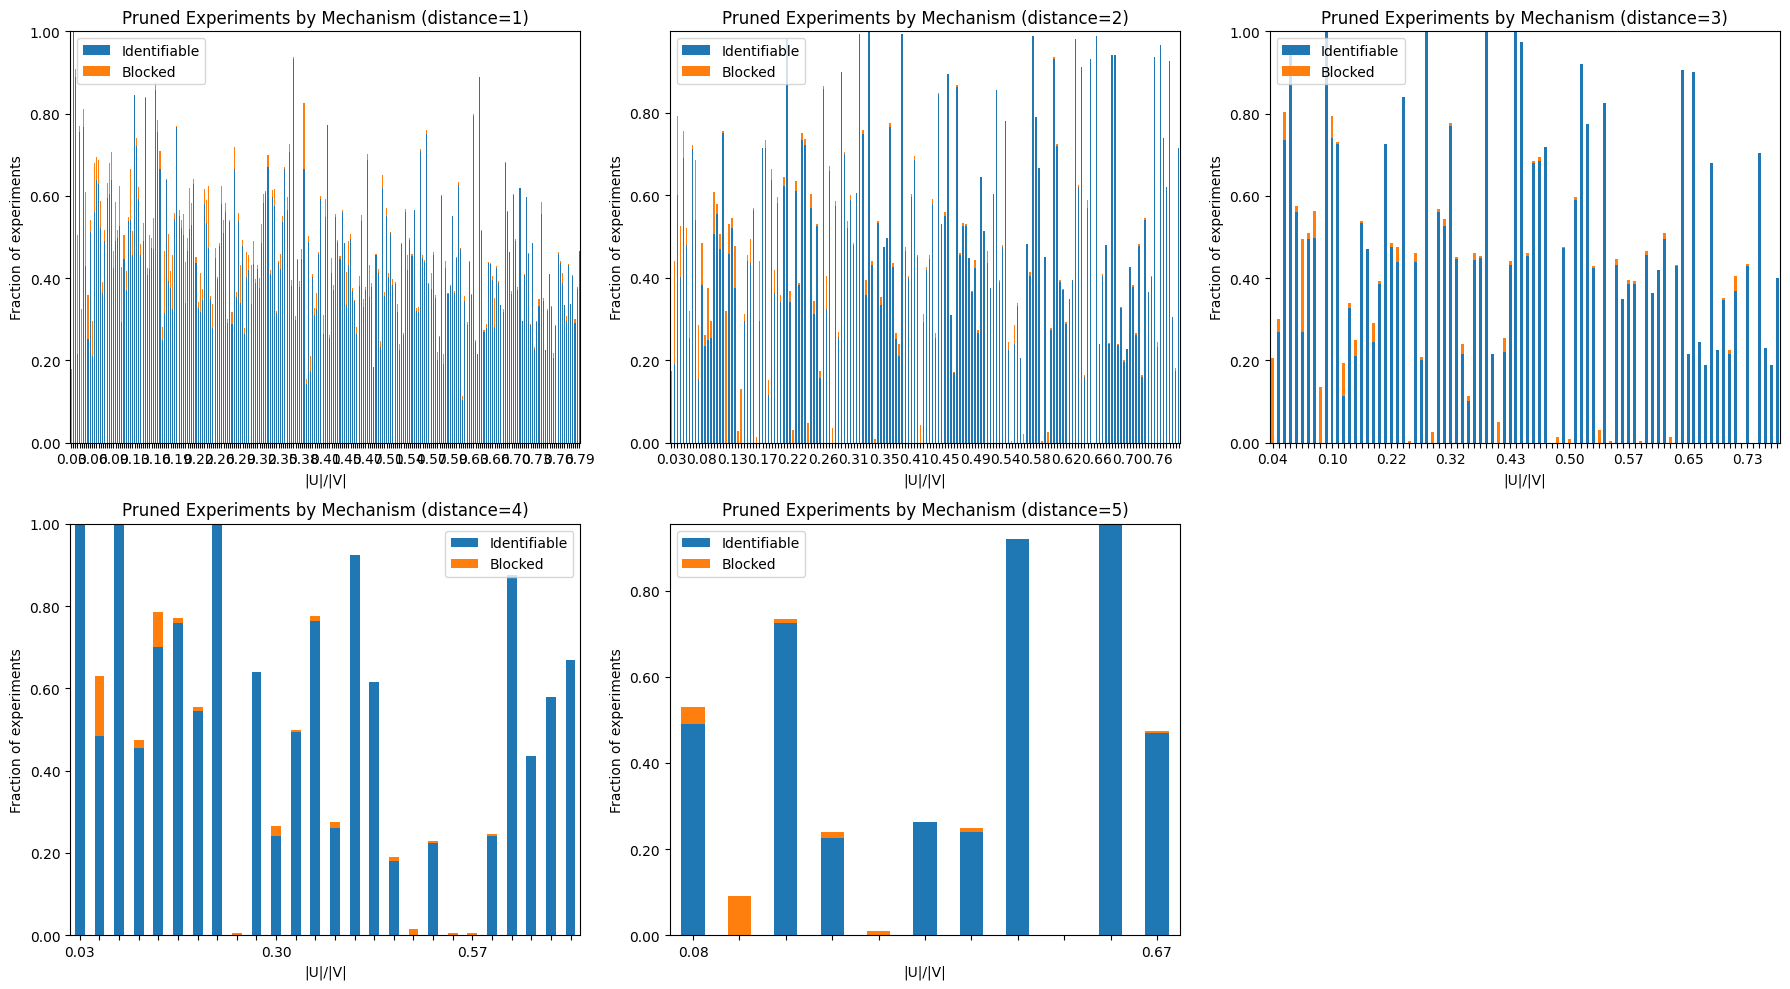

In [88]:
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

n_rows=2
n_cols=3
# Build figure in this cell to ensure render
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
flat_axes = axes.flatten()

source_df = df if not df.empty else df_cf

distances = [1,2,3,4,5]

for idx, dist in enumerate(distances):
    ax = flat_axes[idx]

    mask = source_df["min_intervention_outcome_dist"] == dist
    d = source_df.loc[mask]

    if d.empty:
        ax.set_title(f"Pruned Experiments by Mechanism (distance={dist})\nNo data")
        ax.set_xlabel("|U|/|V|")
        ax.set_ylabel("Fraction of experiments")
        continue

    p = pd.DataFrame({
        "fraction_id": d["id_pruned"] / d["n_experiments"],
        "fraction_blocked": d["blocked_pruned"] / d["n_experiments"],
        "fraction_confounders": d["n_confounders"] / d["n_vars"],
    })

    p = p.groupby("fraction_confounders", as_index=True)[["fraction_id", "fraction_blocked"]].mean()
    p.index = p.index.round(2)

    p.plot(kind="bar", stacked=True, ax=ax)

    ax.set_xlabel("|U|/|V|")
    ax.set_ylabel("Fraction of experiments")
    ax.set_title(f"Pruned Experiments by Mechanism (distance={dist})")
    ax.legend(["Identifiable", "Blocked"])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

    xlabels = [f"{v:.2f}" if i % 10 == 0 else "" for i, v in enumerate(p.index)]
    ax.set_xticklabels(xlabels, rotation=0)

# hide unused panels
for j in range(len(distances), len(flat_axes)):
    flat_axes[j].set_visible(False)

fig.tight_layout()
plt.show()

## Different $R^*_\theta$

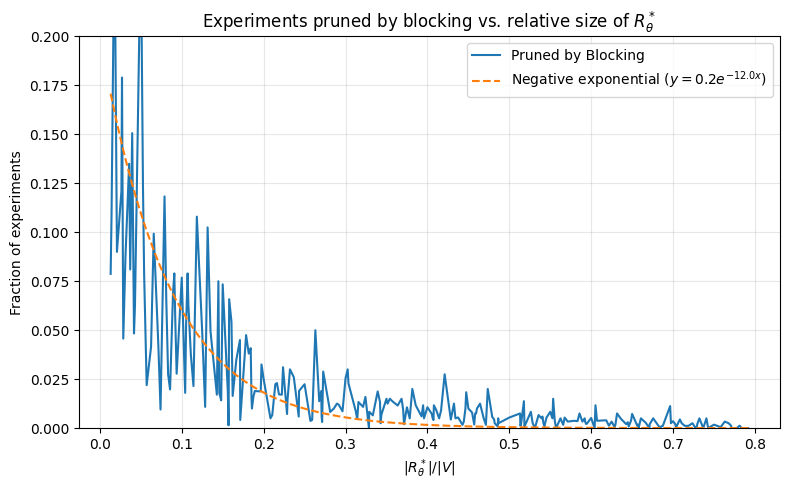

In [6]:
plot_df = (
    df.assign(
        r_star_frac=df["n_R_theta_star"] / df["n_vars"],
        fraction_id=df["id_pruned"] / df["n_experiments"],
        fraction_blocked=df["blocked_pruned"] / df["n_experiments"],
    )
    .groupby("r_star_frac", as_index=False)[["fraction_id", "fraction_blocked"]]
    .mean()
    .sort_values("r_star_frac")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_df["r_star_frac"], plot_df["fraction_blocked"], label="Pruned by Blocking")
# plt.plot(plot_df["r_star_frac"], plot_df["fraction_id"], label="Pruned by ID")

# Negative exponential curve: y = a * exp(-b x)
x_exp = np.linspace(plot_df["r_star_frac"].min(), plot_df["r_star_frac"].max(), 300)
a, b = 0.2, 12.0
y_exp = a * np.exp(-b * x_exp)
plt.plot(x_exp, y_exp, linestyle="--", label=rf"Negative exponential ($y={a}e^{{-{b}x}}$)")

plt.xlabel(r"$|R^*_\theta|/|V|$")
plt.ylabel("Fraction of experiments")
plt.title(r"Experiments pruned by blocking vs. relative size of $R^*_\theta$")
plt.ylim(0, 0.2)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


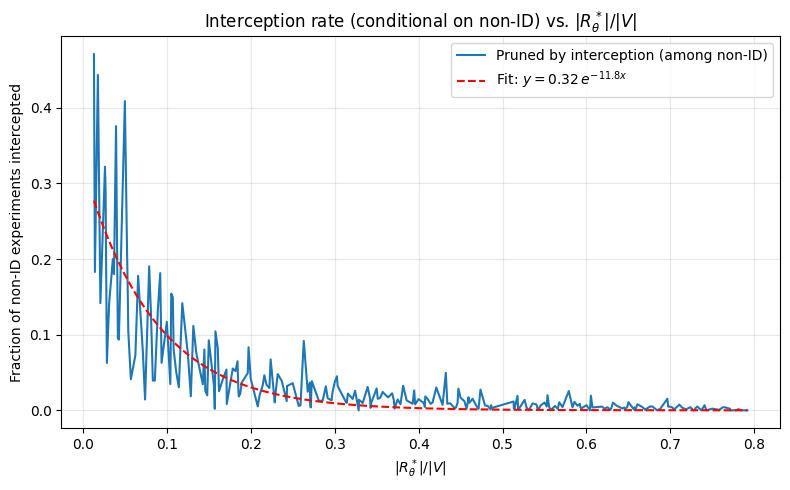

Fitted parameters: a=0.324, b=11.8


In [10]:
plot_df = (
    df.assign(
        r_star_frac=df["n_R_theta_star"] / df["n_vars"],
        non_id=df["n_experiments"] - df["id_pruned"],
        fraction_blocked_given_non_id=df["blocked_pruned"] / (df["n_experiments"] - df["id_pruned"]),
    )
    .query("non_id > 0")  # avoid division by zero
    .groupby("r_star_frac", as_index=False)[["fraction_blocked_given_non_id"]]
    .mean()
    .sort_values("r_star_frac")
)

plt.figure(figsize=(8, 5))
plt.plot(plot_df["r_star_frac"], plot_df["fraction_blocked_given_non_id"], 
         label="Pruned by interception (among non-ID)")

# Fit exponential curve
from scipy.optimize import curve_fit
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

popt, _ = curve_fit(exp_decay, plot_df["r_star_frac"], plot_df["fraction_blocked_given_non_id"], 
                    p0=[0.3, 10.0], maxfev=5000)
a_fit, b_fit = popt

x_exp = np.linspace(plot_df["r_star_frac"].min(), plot_df["r_star_frac"].max(), 300)
y_exp = exp_decay(x_exp, a_fit, b_fit)
plt.plot(x_exp, y_exp, linestyle="--", color="red",
         label=rf"Fit: $y={a_fit:.2f}\,e^{{-{b_fit:.1f}x}}$")

plt.xlabel(r"$|R^*_\theta|/|V|$")
plt.ylabel("Fraction of non-ID experiments intercepted")
plt.title(r"Interception rate (conditional on non-ID) vs. $|R^*_\theta|/|V|$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fitted parameters: a={a_fit:.3f}, b={b_fit:.1f}")

In [9]:
# 1. Breakdown by graph size category
df['graph_size'] = pd.cut(df['n_vars'], bins=[0, 10, 30, 100], 
                          labels=['small', 'medium', 'large'])
df.groupby('graph_size')[['fraction_pruned', 'id_pruned', 'blocked_pruned']].mean()

# 2. The conditional blocking rate vs R*_theta
df['non_id_experiments'] = df['n_experiments'] - df['id_pruned']
df['blocked_rate_given_non_id'] = df['blocked_pruned'] / df['non_id_experiments']
df['r_theta_star_ratio'] = df['n_R_theta_star'] / df['n_vars']

# 3. Total pruning rate by graph (which graphs benefit most?)
df.groupby('graph')['fraction_pruned'].describe()

# 4. How often is blocking the *only* mechanism that prunes?
df['only_blocking_useful'] = (df['id_pruned'] == 0) & (df['blocked_pruned'] > 0)
df['only_blocking_useful'].mean()

np.float64(0.16472727272727272)

## Paper-ready Plots

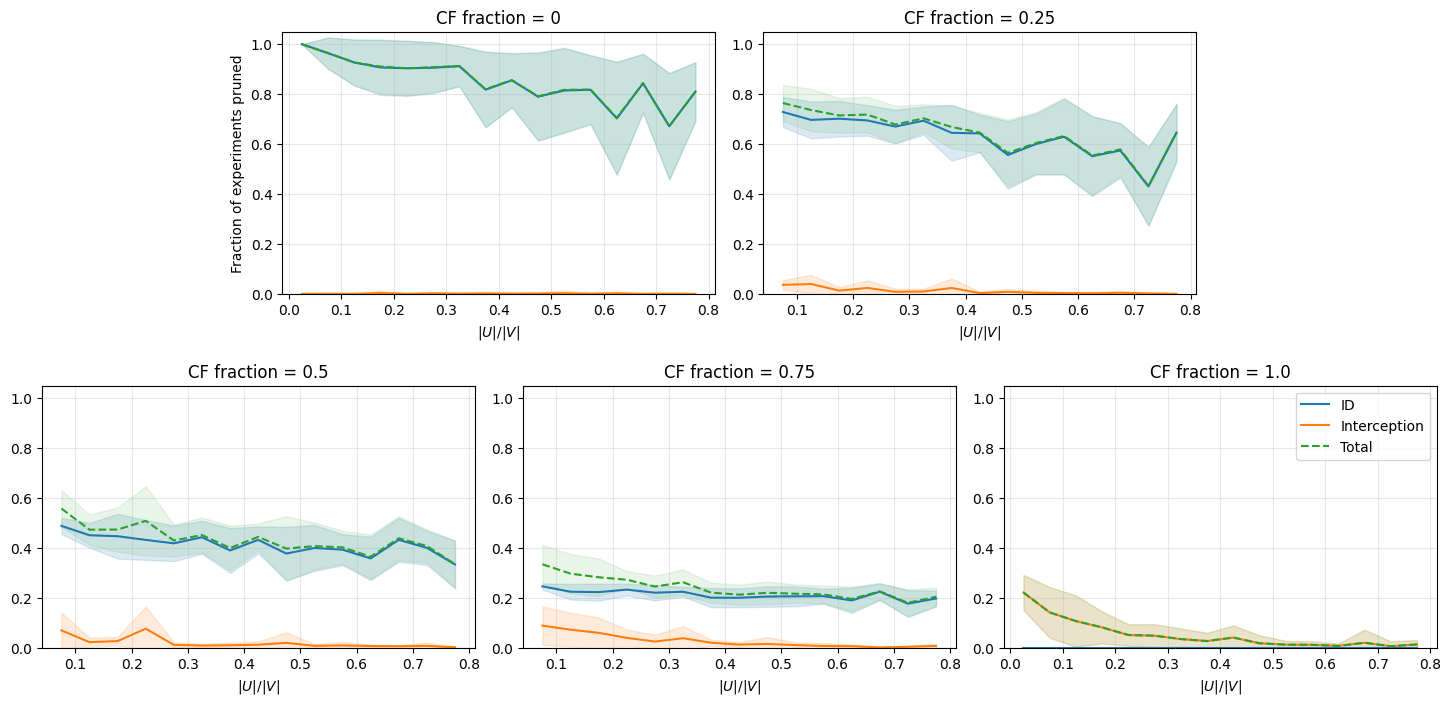

In [13]:
fig = plt.figure(figsize=(18, 8))
gs = fig.add_gridspec(2, 6, hspace=0.35, wspace=0.25)

# Centered layout: 2 plots on top row, 3 on bottom row
ax0 = fig.add_subplot(gs[0, 1:3])  # top-left (centered)
ax1 = fig.add_subplot(gs[0, 3:5], sharey=ax0)  # top-right (centered)
ax2 = fig.add_subplot(gs[1, 0:2], sharey=ax0)  # bottom-left
ax3 = fig.add_subplot(gs[1, 2:4], sharey=ax0)  # bottom-middle
ax4 = fig.add_subplot(gs[1, 4:6], sharey=ax0)  # bottom-right
axes = [ax0, ax1, ax2, ax3, ax4]

for ax, cf in zip(axes, CF_fractions):
    sub = df[df["fraction_cf"].between(cf - 0.01, cf + 0.01)].copy()
    sub["uv_bin"] = pd.cut(sub["u_v_ratio"], bins=np.linspace(0, 0.8, 17))
    sub["uv_mid"] = sub["uv_bin"].apply(lambda x: x.mid if pd.notna(x) else np.nan)
    sub["fraction_id"] = sub["id_pruned"] / sub["n_experiments"]
    sub["fraction_blocked"] = sub["blocked_pruned"] / sub["n_experiments"]
    sub["fraction_total"] = sub["fraction_pruned"]

    grouped = sub.groupby("uv_mid", as_index=False).agg(
        id_mean=("fraction_id", "mean"), id_std=("fraction_id", "std"),
        bl_mean=("fraction_blocked", "mean"), bl_std=("fraction_blocked", "std"),
        tot_mean=("fraction_total", "mean"), tot_std=("fraction_total", "std"),
        count=("fraction_id", "count"),
    ).dropna()

    x = grouped["uv_mid"]
    ax.plot(x, grouped["id_mean"], color="tab:blue", label="ID")
    ax.fill_between(x, grouped["id_mean"] - grouped["id_std"],
                    grouped["id_mean"] + grouped["id_std"], alpha=0.15, color="tab:blue")
    ax.plot(x, grouped["bl_mean"], color="tab:orange", label="Interception")
    ax.fill_between(x, grouped["bl_mean"] - grouped["bl_std"],
                    grouped["bl_mean"] + grouped["bl_std"], alpha=0.15, color="tab:orange")
    ax.plot(x, grouped["tot_mean"], color="tab:green", linestyle="--", label="Total")
    ax.fill_between(x, grouped["tot_mean"] - grouped["tot_std"],
                    grouped["tot_mean"] + grouped["tot_std"], alpha=0.1, color="tab:green")

    ax.set_title(f"CF fraction = {cf}")
    ax.set_xlabel(r"$|U|/|V|$")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Fraction of experiments pruned")
axes[-1].legend(loc="upper right")

plt.savefig("algorithm_evaluation/results/fig_cf_fraction_lines.png", dpi=500, bbox_inches="tight")
plt.show()

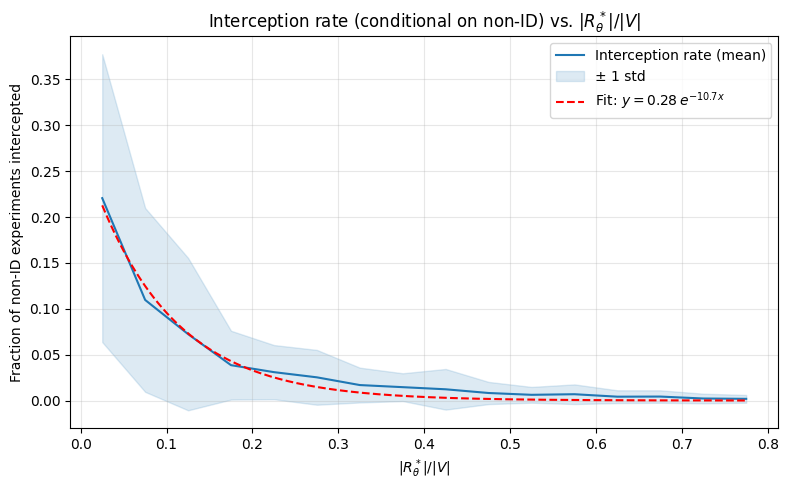

Fit: a=0.278, b=10.7


In [15]:
sub = df.assign(
    r_star_frac=df["n_R_theta_star"] / df["n_vars"],
    non_id=df["n_experiments"] - df["id_pruned"],
    bl_cond=df["blocked_pruned"] / (df["n_experiments"] - df["id_pruned"]),
).query("non_id > 0").copy()

sub["r_bin"] = pd.cut(sub["r_star_frac"], bins=np.linspace(0, 0.85, 18))
sub["r_mid"] = sub["r_bin"].apply(lambda x: x.mid if pd.notna(x) else np.nan)

grouped = sub.groupby("r_mid", as_index=False).agg(
    mean=("bl_cond", "mean"), std=("bl_cond", "std"), count=("bl_cond", "count"),
).dropna()

# Convert categorical bin midpoints to numeric for fitting/plotting
grouped["r_mid"] = grouped["r_mid"].astype(float)

from scipy.optimize import curve_fit
def exp_decay(x, a, b):
    return a * np.exp(-b * x)
popt, _ = curve_fit(exp_decay, grouped["r_mid"].to_numpy(), grouped["mean"].to_numpy(), p0=[0.3, 10.0])
a_fit, b_fit = popt

plt.figure(figsize=(8, 5))
x = grouped["r_mid"].to_numpy()
plt.plot(x, grouped["mean"], color="tab:blue", label="Interception rate (mean)")
plt.fill_between(x, grouped["mean"] - grouped["std"], grouped["mean"] + grouped["std"],
                 alpha=0.15, color="tab:blue", label="± 1 std")
x_fit = np.linspace(x.min(), x.max(), 300)
plt.plot(x_fit, exp_decay(x_fit, *popt), "--", color="red",
         label=rf"Fit: $y={a_fit:.2f}\,e^{{-{b_fit:.1f}x}}$")
plt.xlabel(r"$|R^*_\theta|/|V|$")
plt.ylabel("Fraction of non-ID experiments intercepted")
plt.title(r"Interception rate (conditional on non-ID) vs. $|R^*_\theta|/|V|$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("algorithm_evaluation/results/fig_interception_vs_rstar.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Fit: a={a_fit:.3f}, b={b_fit:.1f}")

In [16]:
summary = (
    df.assign(
        frac_id=df["id_pruned"] / df["n_experiments"],
        frac_bl=df["blocked_pruned"] / df["n_experiments"],
    )
    .groupby("graph")
    .agg(
        n_vars=("n_vars", "first"),
        n_sims=("sim", "count"),
        uv_mean=("u_v_ratio", "mean"),
        r_star_mean=("n_R_theta_star", "mean"),
        id_mean=("frac_id", "mean"),
        bl_mean=("frac_bl", "mean"),
        total_mean=("fraction_pruned", "mean"),
    )
    .sort_values("n_vars")
    .round(3)
)
print(summary.to_latex(index=True))

\begin{tabular}{lrrrrrrr}
\toprule
 & n_vars & n_sims & uv_mean & r_star_mean & id_mean & bl_mean & total_mean \\
graph &  &  &  &  &  &  &  \\
\midrule
asia.bif & 8 & 250 & 0.478000 & 3.736000 & 0.318000 & 0.013000 & 0.331000 \\
sachs.bif & 11 & 250 & 0.450000 & 4.744000 & 0.329000 & 0.016000 & 0.346000 \\
child.bif & 20 & 250 & 0.443000 & 7.892000 & 0.395000 & 0.032000 & 0.427000 \\
insurance.bif & 27 & 250 & 0.423000 & 10.316000 & 0.394000 & 0.010000 & 0.403000 \\
water.bif & 32 & 250 & 0.425000 & 12.284000 & 0.410000 & 0.011000 & 0.422000 \\
mildew.bif & 35 & 250 & 0.423000 & 13.928000 & 0.428000 & 0.005000 & 0.433000 \\
alarm.bif & 37 & 250 & 0.427000 & 13.476000 & 0.457000 & 0.023000 & 0.480000 \\
barley.bif & 48 & 250 & 0.438000 & 18.836000 & 0.434000 & 0.012000 & 0.446000 \\
hailfinder.bif & 56 & 250 & 0.407000 & 18.316000 & 0.462000 & 0.039000 & 0.501000 \\
hepar2.bif & 70 & 250 & 0.387000 & 21.404000 & 0.472000 & 0.010000 & 0.483000 \\
win95pts.bif & 76 & 250 & 0.430000 & 23.

In [17]:
# Overall stats
print("=== Overall ===")
print(f"Total simulations: {len(df)}")
print(f"Mean total pruning: {df['fraction_pruned'].mean():.3f}")
print(f"Mean ID pruning: {(df['id_pruned']/df['n_experiments']).mean():.3f}")
print(f"Mean interception pruning: {(df['blocked_pruned']/df['n_experiments']).mean():.3f}")

# Complementarity
only_id = ((df['id_pruned'] > 0) & (df['blocked_pruned'] == 0)).mean()
only_bl = ((df['id_pruned'] == 0) & (df['blocked_pruned'] > 0)).mean()
both = ((df['id_pruned'] > 0) & (df['blocked_pruned'] > 0)).mean()
neither = ((df['id_pruned'] == 0) & (df['blocked_pruned'] == 0)).mean()
print(f"\n=== Complementarity ===")
print(f"Only ID useful: {only_id:.3f}")
print(f"Only interception useful: {only_bl:.3f}")
print(f"Both useful: {both:.3f}")
print(f"Neither useful: {neither:.3f}")

# By CF fraction
print("\n=== By CF fraction ===")
for cf in [0, 0.25, 0.5, 0.75, 1.0]:
    sub = df[df["fraction_cf"].between(cf - 0.01, cf + 0.01)]
    print(f"CF={cf}: total={sub['fraction_pruned'].mean():.3f}, "
          f"ID={sub['id_pruned'].mean()/sub['n_experiments'].mean():.3f}, "
          f"intercept={sub['blocked_pruned'].mean()/sub['n_experiments'].mean():.3f}")

=== Overall ===
Total simulations: 2750
Mean total pruning: 0.435
Mean ID pruning: 0.416
Mean interception pruning: 0.020

=== Complementarity ===
Only ID useful: 0.377
Only interception useful: 0.165
Both useful: 0.423
Neither useful: 0.035

=== By CF fraction ===
CF=0: total=0.832, ID=0.831, intercept=0.001
CF=0.25: total=0.637, ID=0.625, intercept=0.012
CF=0.5: total=0.427, ID=0.408, intercept=0.019
CF=0.75: total=0.237, ID=0.210, intercept=0.027
CF=1.0: total=0.037, ID=0.000, intercept=0.037
